<a href="https://colab.research.google.com/github/A-Vineela/IIIT-H-Projects-and-Labs/blob/main/Module-4/Lab/Lab-1/Banknote_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [15]:
data=pd.read_csv("data_banknote_authentication.csv")
data.head()

,3.6216,8.6661,-2.8073,-0.44699,0
0,4.54590,8.1674,-2.4586,-1.46210,0
1,3.86600,-2.6383,1.9242,0.10645,0
2,3.45660,9.5228,-4.0112,-3.59440,0
3,0.32924,-4.4552,4.5718,-0.98880,0
4,4.36840,9.6718,-3.9606,-3.16250,0


In [16]:
X=data.iloc[: , :-1].values
y=data.iloc[: , -1].values
# Convert labels:
# 0 -> -1
# 1 -> +1
y=np.where(y==0,-1,1)

In [17]:
scaler=StandardScaler()
X=scaler.fit_transform(X)

In [18]:
bias=-1*np.ones((X.shape[0],1))
X=np.hstack((X,bias))

In [19]:
X_train , X_test , y_train , y_test=train_test_split(X ,y , test_size=0.2,random_state=42)

In [20]:
def perceptron_algo_plot(X, Y):
    #Train perceptron and plot total loss in each epoch.
    w=np.zeros(len(X[0]))
    eta=0.1
    n=30
    errors=[]
    for epoch in range(n):
        total_error=0
        for i,x in enumerate(X):
            if(np.dot(X[i],w)*Y[i])<=0:
                total_error+=(np.dot(X[i],w)*Y[i])
                w=w+eta*X[i]*Y[i]
        errors.append(-total_error)
    plt.plot(errors)
    plt.xlabel("Epoch")
    plt.ylabel("Total Loss")
    plt.title("Perceptron Error Plot : Banknote Dataset")
    return w

Final weights:
[-1.91170693 -2.01664387 -1.5760091  -0.19206409  0.7       ]


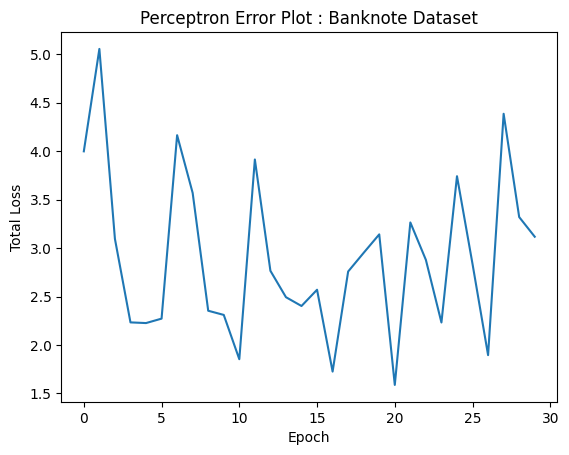

In [21]:
w = perceptron_algo_plot(X_train, y_train)
print("Final weights:")
print(w)

In [22]:
def predict(X,w):
    predictions=[]
    for x in X:
        y=np.sign(np.dot(x , w))
        predictions.append(y)
    return np.array(predictions)

In [23]:
y_pred=predict(X_test,w)
accuracy=np.mean(y_pred==y_test)
print("Accuracy:",accuracy*100,"%")

Accuracy: 97.45454545454545 %
